In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder


In [53]:
data=pd.read_csv('survey_lung_cancer.csv')
data.head()


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,MALE,69,0,1,1,0,0,1,0,1,1,1,1,1,1,YES
1,MALE,74,1,0,0,0,1,1,1,0,0,0,1,1,1,YES
2,FEMALE,59,0,0,0,1,0,1,0,1,0,1,1,0,1,NO
3,MALE,63,1,1,1,0,0,0,0,0,1,0,0,1,1,NO
4,FEMALE,63,0,1,0,0,0,0,0,1,0,1,1,0,0,NO


In [54]:
data['GENDER']=data['GENDER'].map({"MALE":0,"FEMALE":1})
data['LUNG_CANCER']=data['LUNG_CANCER'].map({"YES":1,"NO":0})
data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,0,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,0,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,1,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,0,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,1,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


In [55]:
data.shape

(309, 16)

In [56]:
#dependent variable
X=data.iloc[:,0:-1]
X

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,0,69,0,1,1,0,0,1,0,1,1,1,1,1,1
1,0,74,1,0,0,0,1,1,1,0,0,0,1,1,1
2,1,59,0,0,0,1,0,1,0,1,0,1,1,0,1
3,0,63,1,1,1,0,0,0,0,0,1,0,0,1,1
4,1,63,0,1,0,0,0,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,1,56,0,0,0,1,1,1,0,0,1,1,1,1,0
305,0,70,1,0,0,0,0,1,1,1,1,1,1,0,1
306,0,58,1,0,0,0,0,0,1,1,1,1,0,0,1
307,0,67,1,0,1,0,0,1,1,0,1,1,1,0,1


In [57]:
#independent variable
y=data['LUNG_CANCER']
y=y.values.ravel()
y

array([1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [58]:
dependent=data.iloc[:,:-1]
independent=data.iloc[:,-1]
X_train,X_test,y_train,y_test=train_test_split(dependent,independent,test_size=0.3,random_state=42)


In [59]:
#logistic regression
log_reg=LogisticRegression(max_iter=200)
log_reg.fit(X_train,y_train)
prediction=log_reg.predict(X_test)
prediction

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1])

In [60]:
#KNN classifier
knn=KNeighborsClassifier(n_neighbors=3,metric='minkowski',p=2)
knn.fit(X_train,y_train)
prediction1=knn.predict(X_test)
prediction1

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1])

In [61]:
#Decision Tree
tree=DecisionTreeClassifier(criterion='entropy',random_state=0)
tree.fit(X_train,y_train)
prediction2=tree.predict(X_test)
prediction2

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1])

In [62]:
#SVM classifier
svm=OneVsRestClassifier(BaggingClassifier(SVC(C=10,kernel='rbf',random_state=9,probability=True),n_jobs=-1))
svm.fit(X_train,y_train)
prediction3=svm.predict(X_test)
prediction3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1])

In [63]:
#Naive Bayes
nb=GaussianNB()
nb.fit(X_train,y_train)
prediction4=nb.predict(X_test)
prediction4

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1])

In [64]:
#Random Forest
rf=RandomForestClassifier(n_estimators=100,random_state=0)
rf.fit(X_train,y_train)
prediction5=rf.predict(X_test)
prediction5

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1])

In [65]:
def evaluate_model(y_true,y_pred,model_name,results_dict):
  accuracy=accuracy_score(y_true,y_pred)
  precision=precision_score(y_true,y_pred)
  recall=recall_score(y_true,y_pred)
  f1=f1_score(y_true,y_pred)

  results_dict[model_name]=accuracy
  print(f"{model_name} Metrics:")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1 Score: {f1:.4f}")

In [66]:
accuracy_result={}
evaluate_model(y_test,prediction,'Logistic Regression',accuracy_result)
evaluate_model(y_test,prediction1,'KNN Classifier',accuracy_result)
evaluate_model(y_test,prediction2,'Decision Tree',accuracy_result)
evaluate_model(y_test,prediction3,'SVM Classifier',accuracy_result)
evaluate_model(y_test,prediction4,'Naive Bayes',accuracy_result)
evaluate_model(y_test,prediction5,'Random Forest',accuracy_result)

Logistic Regression Metrics:
Accuracy: 0.9785
Precision: 0.9773
Recall: 1.0000
F1 Score: 0.9885
KNN Classifier Metrics:
Accuracy: 0.9247
Precision: 0.9438
Recall: 0.9767
F1 Score: 0.9600
Decision Tree Metrics:
Accuracy: 0.9247
Precision: 0.9647
Recall: 0.9535
F1 Score: 0.9591
SVM Classifier Metrics:
Accuracy: 0.9247
Precision: 0.9247
Recall: 1.0000
F1 Score: 0.9609
Naive Bayes Metrics:
Accuracy: 0.9570
Precision: 0.9659
Recall: 0.9884
F1 Score: 0.9770
Random Forest Metrics:
Accuracy: 0.9677
Precision: 0.9770
Recall: 0.9884
F1 Score: 0.9827


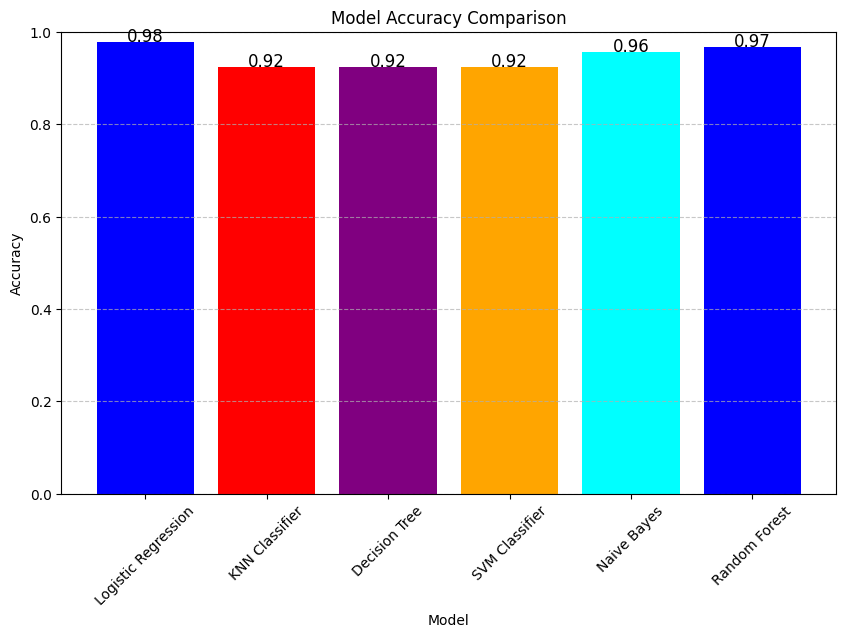

In [67]:
plt.figure(figsize=(10,6))
plt.bar(accuracy_result.keys(),accuracy_result.values(),color=['blue','red','purple','orange','cyan'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)


for i ,(model,accuracy) in enumerate(accuracy_result.items()):
  plt.text(i,accuracy,f"{accuracy:.2f}" ,ha="center" , fontsize=12)
plt.show()




In [68]:
def plot_confusion_matrix(y_true,y_pred,model_name):
  cm=confusion_matrix(y_true,y_pred)
  sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.title(f"Confusion Matrix for {model_name}")
  plt.show()

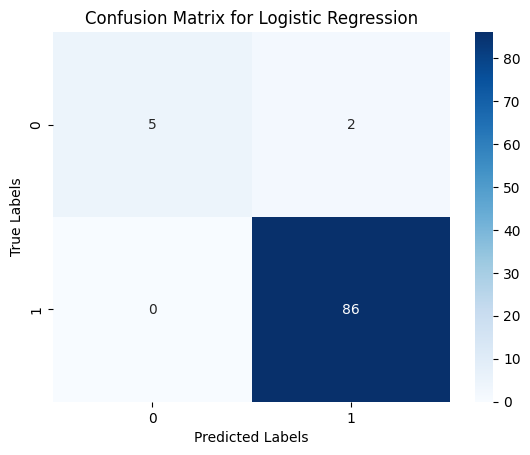

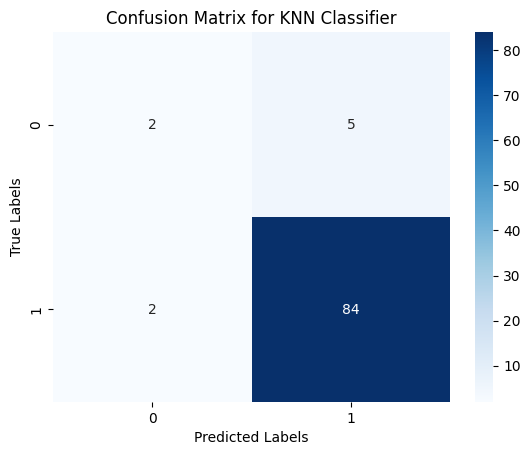

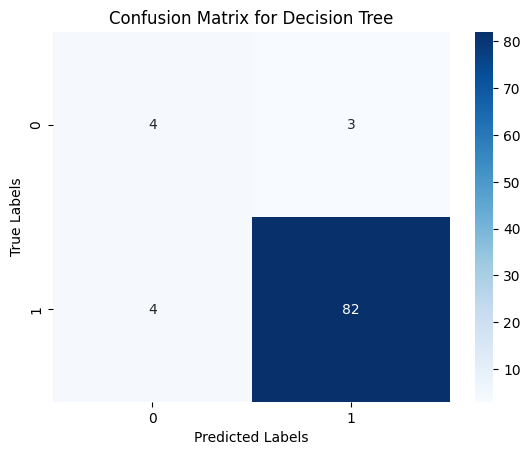

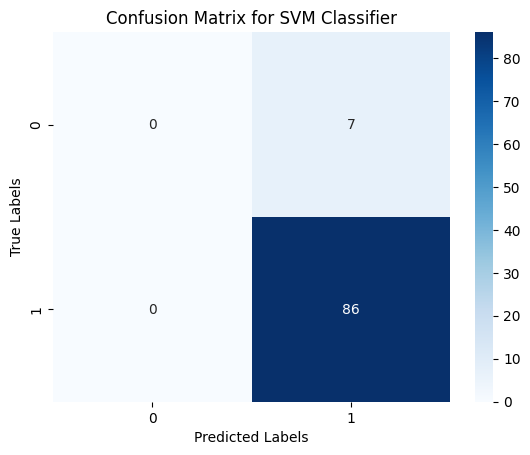

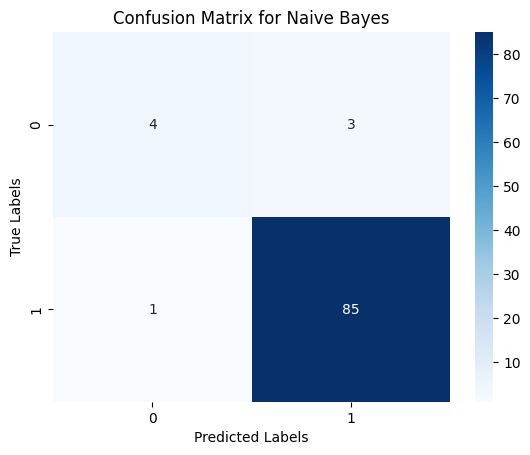

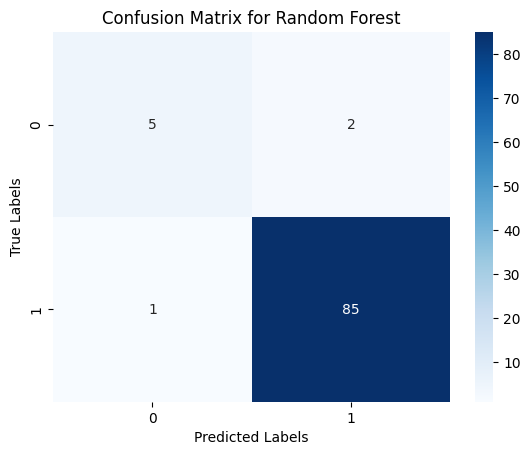

In [69]:
plot_confusion_matrix(y_test,prediction,'Logistic Regression')
plot_confusion_matrix(y_test,prediction1,'KNN Classifier')
plot_confusion_matrix(y_test,prediction2,'Decision Tree')
plot_confusion_matrix(y_test,prediction3,'SVM Classifier')
plot_confusion_matrix(y_test,prediction4,'Naive Bayes')
plot_confusion_matrix(y_test,prediction5,'Random Forest')


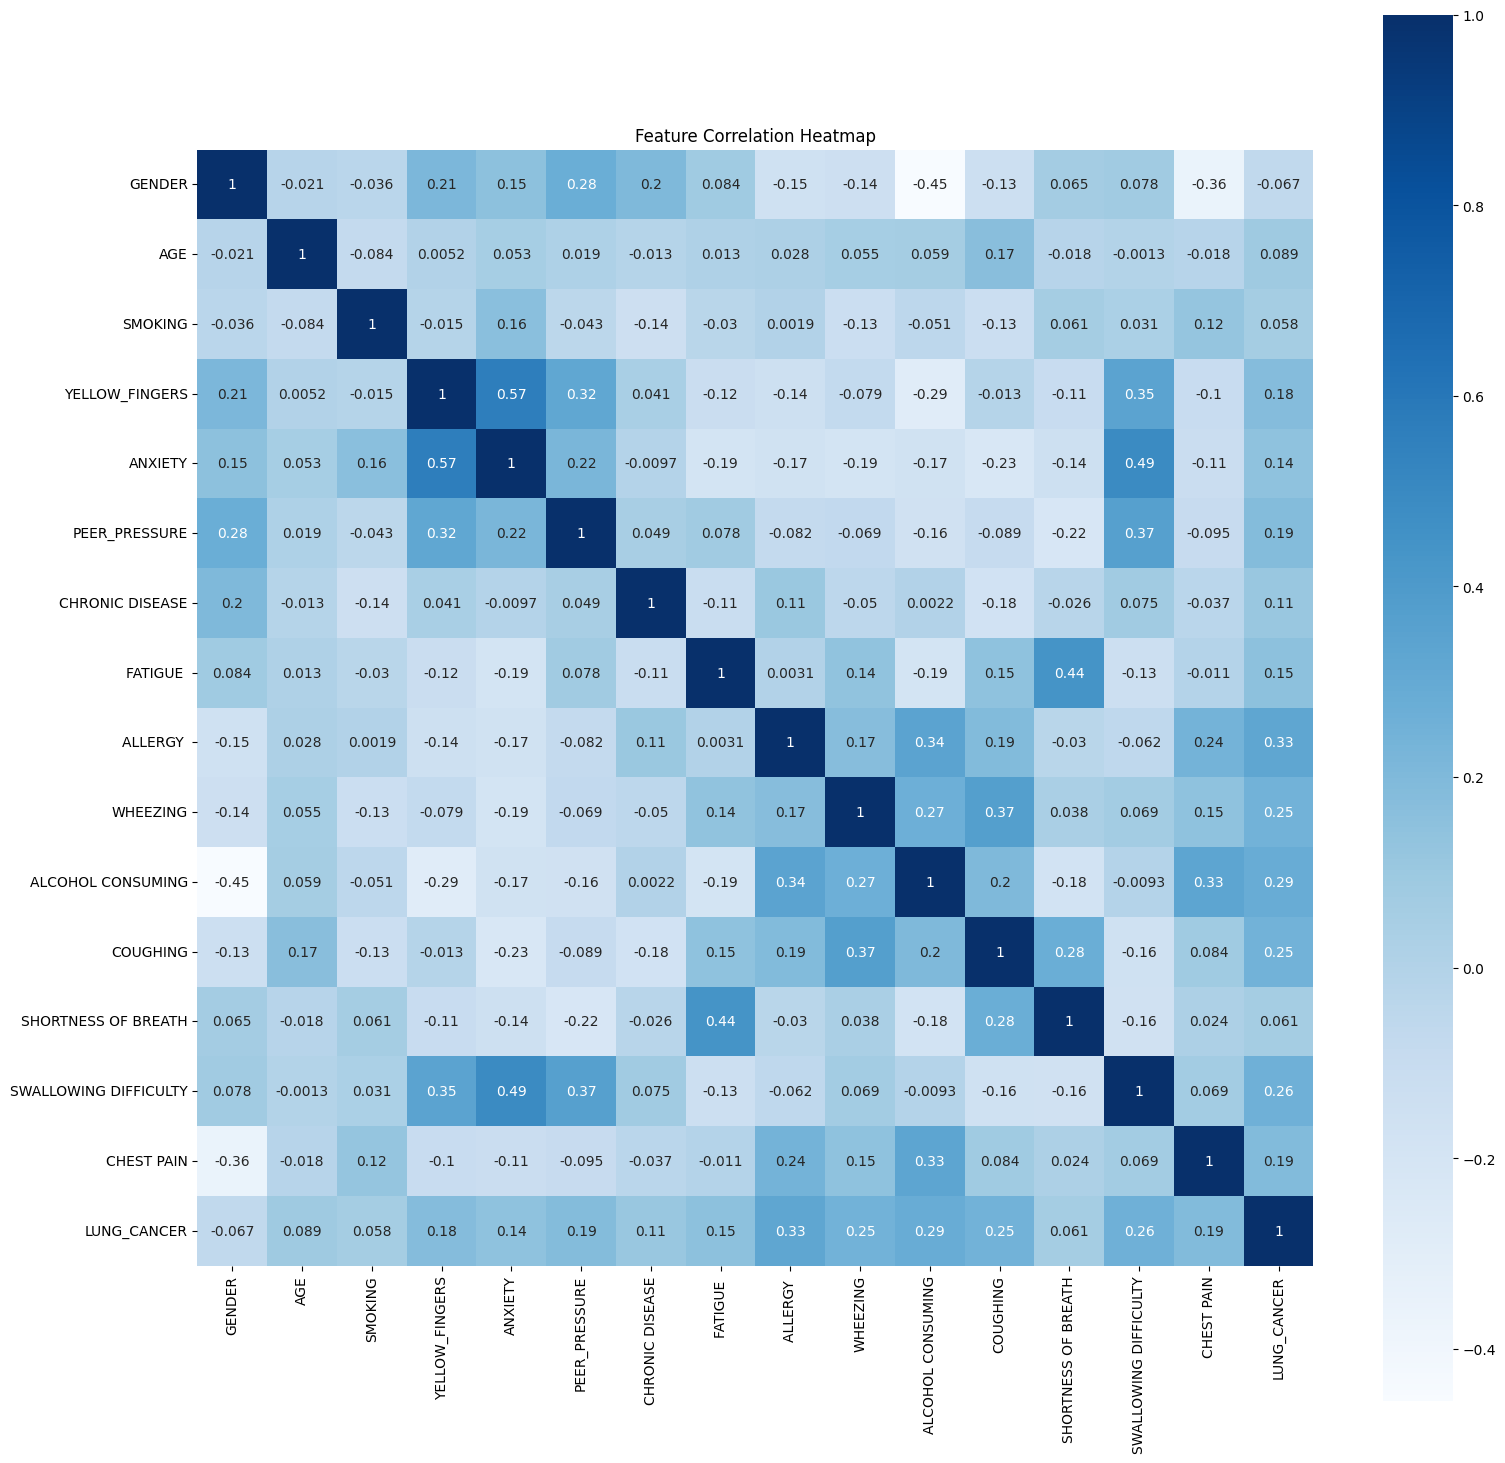

In [70]:
correlation=data.corr()
plt.figure(figsize=(18,18))
sns.heatmap(correlation,annot=True,cmap='Blues',square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

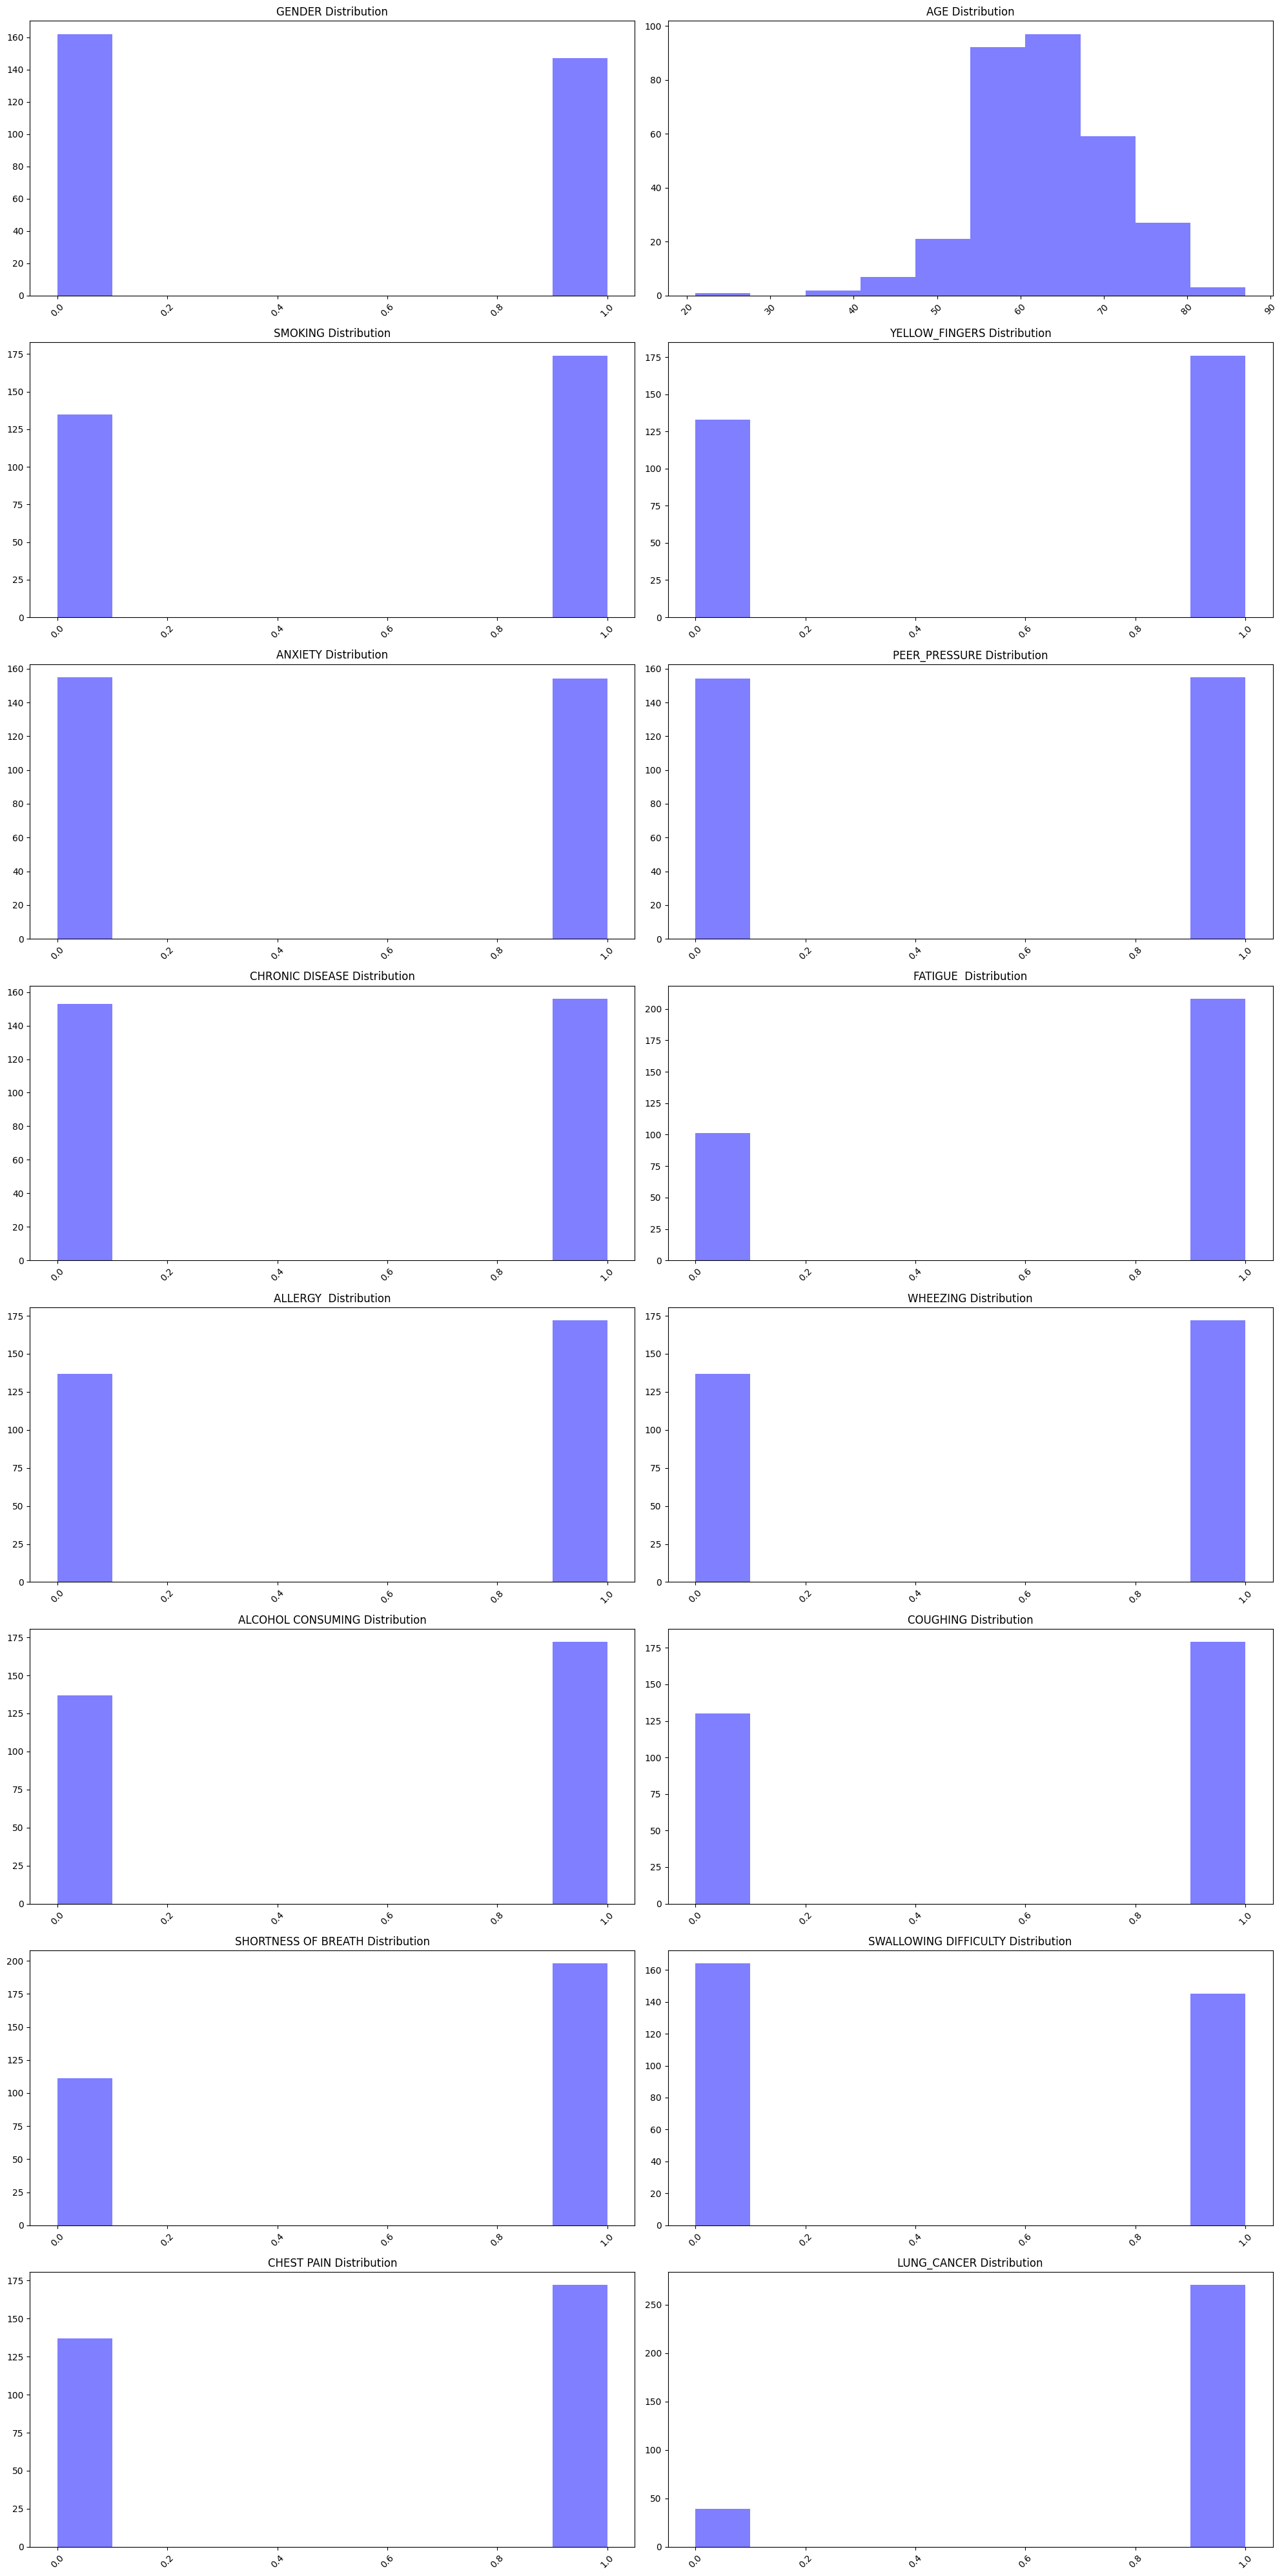

In [71]:
#Feature Distribution

num_list=list(data.columns)
rows=(len(num_list)//2) + (len(num_list)%2)

plt.figure(figsize=(20,40))
for i in range(len(num_list)):
  plt.subplot(rows,2,i+1)
  plt.title(f"{num_list[i]} Distribution")
  plt.xticks(rotation=45)
  plt.hist(data[num_list[i]],color='blue', alpha=0.5)
plt.tight_layout()
plt.show()
